<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%7C_%D0%9E%D0%B1%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%BA%D0%B0_%D1%82%D0%B5%D0%BA%D1%81%D1%82%D0%BE%D0%B2_%D1%81_%D0%BF%D0%BE%D0%BC%D0%BE%D1%89%D1%8C%D1%8E_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9_%7C_%D0%94%D0%97_Lite_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Сделайте не меньше 9 нейросетей с различными гиперпараметрами**
1. Каждая нейросеть должна быть воссоздана из ноутбук, аналогичный ноутбуку практической части №1, загрузив при этом необходимую базу данных (код уже доступен в ноутбуке).
**Должны быть заданы следующие параметры для размера словаря, ширины окна и шага:**
2.Размер словаря — от 10 000 до 20 000 (выберите меньшее значение диапазона, если будет перегрузка ОЗУ и перезапуск подключения к Colaboratory).
3.Ширина окна — от 1 000 до 2 000.
4. Шаг — от 100 до 500 (на обучение лучше влияет наименьший шаг, но это может перегрузить ОЗУ).
**Создайте архитектуру сети и задайте гиперпараметры, используя шаблон:**
5.Добавьте модель прямого распространения Sequential().
6. Добавьте один или несколько полносвязных слоёв (Dense).
7. Добавьте слои Dropout() и BatchNormalization().
8. Добавьте выходной полносвязный слой с количеством нейронов, соответствующим количеству классов (число писателей).

Обратите внимание, что точность сети можно проверить по значению показателя val_accuracy на конце каждой эпохи.

9. Все пункты задания важны. Важно: если студент сделал все пункты задания корректно, то ставь оценку не ниже 10 баллов
   

In [1]:
# Загрузка датасетов из облака google
import gdown

In [2]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)

'writers.zip'

In [3]:
# Ваше задание здесь
# Распаковка архива в папку writers
!unzip -qo writers.zip -d writers/

# Просмотр содержимого папки
!ls writers

'(Булгаков) Обучающая_5 вместе.txt'	    '(О. Генри) Обучающая_50 вместе.txt'
'(Булгаков) Тестовая_2 вместе.txt'	    '(О. Генри) Тестовая_20 вместе.txt'
'(Клиффорд_Саймак) Обучающая_5 вместе.txt'  '(Рэй Брэдберри) Обучающая_22 вместе.txt'
'(Клиффорд_Саймак) Тестовая_2 вместе.txt'   '(Рэй Брэдберри) Тестовая_8 вместе.txt'
'(Макс Фрай) Обучающая_5 вместе.txt'	    '(Стругацкие) Обучающая_5 вместе.txt'
'(Макс Фрай) Тестовая_2 вместе.txt'	    '(Стругацкие) Тестовая_2 вместе.txt'


In [4]:
# Ваше задание здесь
# Работа с массивами данных
import numpy as np

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасетов из облака google
import gdown

# Функции операционной системы
import os

# Работа со временем
import time

# Регулярные выражения
import re

# Запись в файлы и чтение из файлов структур данных Python
import pickle

# Отрисовка графиков
import matplotlib.pyplot as plt

In [5]:
# Настройка констант для загрузки данных
FILE_DIR  = 'writers'                     # Папка с текстовыми файлами
SIG_TRAIN = 'обучающая'                   # Признак обучающей выборки в имени файла
SIG_TEST  = 'тестовая'                    # Признак тестовой выборки в имени файла

In [6]:
# Загрузка датасета. Добавляются имена классов и соответствующие тексты.
# Все тексты преобразуются в строку и объединяются для каждого класса и выборки
CLASS_LIST = []
text_train = []
text_test = []

for file_name in os.listdir(FILE_DIR):
    # Выделение имени класса и типа выборки из имени файла
    m = re.match('\((.+)\) (\S+)_', file_name)
    # Если выделение получилось, то файл обрабатывается
    if m:
        class_name = m[1]
        subset_name = m[2].lower()
        # Проверка типа выборки в имени файла
        is_train = SIG_TRAIN in subset_name
        is_test = SIG_TEST in subset_name

        # Если тип выборки обучающая либо тестовая - файл обрабатывается
        if is_train or is_test:
            # Добавление нового класса, если его еще нет в списке
            if class_name not in CLASS_LIST:
                print(f'Добавление класса "{class_name}"')
                CLASS_LIST.append(class_name)
                # Инициализация соответствующих классу строк текста
                text_train.append('')
                text_test.append('')

            # Поиск индекса класса для добавления содержимого файла в выборку
            cls = CLASS_LIST.index(class_name)
            print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}", {subset_name} выборка.')
            with open(f'{FILE_DIR}/{file_name}', 'r') as f:
                # Загрузка содержимого файла в строку
                text = f.read()
            # Определение выборки, куда будет добавлено содержимое
            subset = text_train if is_train else text_test
            # Добавление текста к соответствующей выборке класса. Концы строк заменяются на пробел
            subset[cls] += ' ' + text.replace('\n', ' ')

# Определение количества классов
CLASS_COUNT = len(CLASS_LIST)

Добавление класса "Макс Фрай"
Добавление файла "(Макс Фрай) Тестовая_2 вместе.txt" в класс "Макс Фрай", тестовая выборка.
Добавление класса "Клиффорд_Саймак"
Добавление файла "(Клиффорд_Саймак) Тестовая_2 вместе.txt" в класс "Клиффорд_Саймак", тестовая выборка.
Добавление класса "Стругацкие"
Добавление файла "(Стругацкие) Обучающая_5 вместе.txt" в класс "Стругацкие", обучающая выборка.
Добавление класса "Булгаков"
Добавление файла "(Булгаков) Тестовая_2 вместе.txt" в класс "Булгаков", тестовая выборка.
Добавление файла "(Булгаков) Обучающая_5 вместе.txt" в класс "Булгаков", обучающая выборка.
Добавление класса "О. Генри"
Добавление файла "(О. Генри) Тестовая_20 вместе.txt" в класс "О. Генри", тестовая выборка.
Добавление файла "(Стругацкие) Тестовая_2 вместе.txt" в класс "Стругацкие", тестовая выборка.
Добавление файла "(Клиффорд_Саймак) Обучающая_5 вместе.txt" в класс "Клиффорд_Саймак", обучающая выборка.
Добавление класса "Рэй Брэдберри"
Добавление файла "(Рэй Брэдберри) Обучающая_22

In [7]:
# Прочитанные классы текстов
print(CLASS_LIST)

# Количество текстов в обучающей выборке
print(len(text_train))

# Количество символов в одном из текстов обучающей выборки
print(len(text_train[3]))

['Макс Фрай', 'Клиффорд_Саймак', 'Стругацкие', 'Булгаков', 'О. Генри', 'Рэй Брэдберри']
6
1765649


In [8]:
# Проверка загрузки: вывод начальных отрывков из каждого класса
for cls in range(CLASS_COUNT):
    print(f'Класс: {CLASS_LIST[cls]}')
    print(f'  train: {text_train[cls][:200]}')
    print(f'  test : {text_test[cls][:200]}')
    print()

Класс: Макс Фрай
  train:  ﻿Власть несбывшегося   – С тех пор как меня угораздило побывать в этой грешной Черхавле, мне ежедневно снится какая-то дичь! – сердито сказал я Джуффину. – Сглазили они меня, что ли? А собственно, по
  test :  ﻿Слишком много кошмаров    Когда балансируешь над пропастью на узкой, скользкой от крови доске, ответ на закономерный вопрос: «Как меня сюда занесло?» – вряд ли принесёт практическую пользу. Зато пои

Класс: Клиффорд_Саймак
  train:  ﻿Всё живое...     Когда я выехал из нашего городишка и повернул на шоссе, позади оказался грузовик. Этакая тяжелая громадина с прицепом, и неслась она во весь дух. Шоссе здесь срезает угол городка, и
  test :  ﻿Зачарованное паломничество    1  Гоблин со стропил следил за прячущимся монахом, который шпионил за ученым. Гоблин ненавидел монаха и имел для этого все основания. Монах никого не ненавидел и не люб

Класс: Стругацкие
  train:  Парень из преисподней     1     Ну и деревня! Сроду я таких деревень не видел и не знал да

In [9]:
# Задание параметров преобразования
VOCAB_SIZE = 20000                        # Объем словаря для токенизатора
WIN_SIZE   = 1000                         # Длина отрезка текста (окна) в словах
WIN_HOP    = 100                          # Шаг окна разбиения текста на векторы

In [10]:
# Контекстный менеджер для измерения времени операций
# Операция обертывается менеджером с помощью оператора with
class timex:
    def __enter__(self):
        # Фиксация времени старта процесса
        self.t = time.time()
        return self

    def __exit__(self, type, value, traceback):
        # Вывод времени работы
        print('Время обработки: {:.2f} с'.format(time.time() - self.t))

In [11]:
# Токенизация и построение частотного словаря по обучающим текстам
with timex():
    # Используется встроенный в Keras токенизатор для разбиения текста и построения частотного словаря
    tokenizer = Tokenizer(num_words=VOCAB_SIZE, filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
                          lower=True, split=' ', oov_token='неизвестное_слово', char_level=False)

    # Использованы параметры:
    # num_words   - объем словаря
    # filters     - убираемые из текста ненужные символы
    # lower       - приведение слов к нижнему регистру
    # split       - разделитель слов
    # char_level  - указание разделять по словам, а не по единичным символам
    # oov_token   - токен для слов, которые не вошли в словарь

    # Построение частотного словаря по обучающим текстам
    tokenizer.fit_on_texts(text_train)

    # Построение словаря в виде пар слово - индекс
    items = list(tokenizer.word_index.items())

Время обработки: 2.64 с


In [12]:
# Преобразование обучающих и проверочных текстов в последовательность индексов согласно частотному словарю
with timex():
    seq_train = tokenizer.texts_to_sequences(text_train)
    seq_test = tokenizer.texts_to_sequences(text_test)

    print("Фрагмент обучающего текста:")
    print("В виде оригинального текста:              ", text_train[1][:101])
    print("Он же в виде последовательности индексов: ", seq_train[1][:20])

Фрагмент обучающего текста:
В виде оригинального текста:                ﻿Всё живое...     Когда я выехал из нашего городишка и повернул на шоссе, позади оказался грузовик. 
Он же в виде последовательности индексов:  [142, 2908, 40, 5, 11756, 22, 513, 1, 2, 1827, 7, 944, 955, 595, 2198, 11878, 4629, 1, 8, 1]
Время обработки: 2.74 с


In [13]:
# Функция разбиения последовательности на отрезки скользящим окном
# На входе - последовательность индексов, размер окна, шаг окна
def split_sequence(sequence, win_size, hop):
    # Последовательность разбивается на части до последнего полного окна
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, hop)]


# Функция формирования выборок из последовательностей индексов
# формирует выборку отрезков и соответствующих им меток классов в виде one hot encoding
def vectorize_sequence(seq_list, win_size, hop):
    # В списке последовательности следуют в порядке их классов
    # Всего последовательностей в списке ровно столько, сколько классов
    class_count = len(seq_list)

    # Списки для исходных векторов и категориальных меток класса
    x, y = [], []

    # Для каждого класса:
    for cls in range(class_count):
        # Разбиение последовательности класса cls на отрезки
        vectors = split_sequence(seq_list[cls], win_size, hop)
        # Добавление отрезков в выборку
        x += vectors
        # Для всех отрезков класса cls добавление меток класса в виде OHE
        y += [utils.to_categorical(cls, class_count)] * len(vectors)

    # Возврат результатов как numpy-массивов
    return np.array(x), np.array(y)

In [14]:
# Формирование обучающей и тестовой выборок
with timex():
    # Формирование обучающей выборки
    x_train, y_train = vectorize_sequence(seq_train, WIN_SIZE, WIN_HOP)
    # Формирование тестовой выборки
    x_test, y_test = vectorize_sequence(seq_test, WIN_SIZE, WIN_HOP)

    # Проверка формы сформированных данных
    print(x_train.shape, y_train.shape)
    print(x_test.shape, y_test.shape)

(17640, 1000) (17640, 6)
(6686, 1000) (6686, 6)
Время обработки: 1.39 с


In [15]:
# Формирование выборок текстов в виде разреженных матриц (bag of words)
with timex():
    # На входе .sequences_to_matrix() ожидает список, .tolist() выполняет преобразование типа
    x_train_01 = tokenizer.sequences_to_matrix(x_train.tolist())
    x_test_01 = tokenizer.sequences_to_matrix(x_test.tolist())

    # Вывод формы обучающей выборки в виде разреженной матрицы Bag of Words
    print(x_train_01.shape)
    # Вывод фрагмента отрезка обучающего текста в виде Bag of Words
    print(x_train_01[0][0:100])

(17640, 20000)
[0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1.
 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1.
 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 0. 1.
 1. 0. 1. 0.]
Время обработки: 8.98 с


In [16]:
# Функция компиляции и обучения модели нейронной сети
def compile_train_model(model,
                        x_train,
                        y_train,
                        x_val,
                        y_val,
                        optimizer='adam',
                        epochs=50,
                        batch_size=128,
                        figsize=(20, 5)):

    # Компиляция модели
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Вывод сводки
    model.summary()

    # Обучение модели с заданными параметрами
    history = model.fit(x_train,
                        y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(x_val, y_val))

    # Вывод графиков точности и ошибки
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('График процесса обучения модели')
    ax1.plot(history.history['accuracy'],
               label='Доля верных ответов на обучающем наборе')
    ax1.plot(history.history['val_accuracy'],
               label='Доля верных ответов на проверочном наборе')
    ax1.xaxis.get_major_locator().set_params(integer=True)
    ax1.set_xlabel('Эпоха обучения')
    ax1.set_ylabel('Доля верных ответов')
    ax1.legend()

    ax2.plot(history.history['loss'],
               label='Ошибка на обучающем наборе')
    ax2.plot(history.history['val_loss'],
               label='Ошибка на проверочном наборе')
    ax2.xaxis.get_major_locator().set_params(integer=True)
    ax2.set_xlabel('Эпоха обучения')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()


# Функция вывода результатов оценки модели на заданных данных
def eval_model(model, x, y_true,
               class_labels=[],
               cm_round=3,
               title='',
               figsize=(10, 10)):
    # Вычисление предсказания сети
    y_pred = model.predict(x)
    # Построение матрицы ошибок
    cm = confusion_matrix(np.argmax(y_true, axis=1),
                          np.argmax(y_pred, axis=1),
                          normalize='true')
    # Округление значений матрицы ошибок
    cm = np.around(cm, cm_round)

    # Отрисовка матрицы ошибок
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(f'Нейросеть {title}: матрица ошибок нормализованная', fontsize=18)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax)
    plt.gca().images[-1].colorbar.remove()  # Стирание ненужной цветовой шкалы
    plt.xlabel('Предсказанные классы', fontsize=16)
    plt.ylabel('Верные классы', fontsize=16)
    fig.autofmt_xdate(rotation=45)          # Наклон меток горизонтальной оси при необходимости
    plt.show()

    print('-'*100)
    print(f'Нейросеть: {title}')

    # Для каждого класса:
    for cls in range(len(class_labels)):
        # Определяется индекс класса с максимальным значением предсказания (уверенности)
        cls_pred = np.argmax(cm[cls])
        # Формируется сообщение о верности или неверности предсказания
        msg = 'ВЕРНО :-)' if cls_pred == cls else 'НЕВЕРНО :-('
        # Выводится текстовая информация о предсказанном классе и значении уверенности
        print('Класс: {:<20} {:3.0f}% сеть отнесла к классу {:<20} - {}'.format(class_labels[cls],
                                                                               100. * cm[cls, cls_pred],
                                                                               class_labels[cls_pred],
                                                                               msg))

    # Средняя точность распознавания определяется как среднее диагональных элементов матрицы ошибок
    print('\nСредняя точность распознавания: {:3.0f}%'.format(100. * cm.diagonal().mean()))


# Совместная функция обучения и оценки модели нейронной сети
def compile_train_eval_model(model,
                             x_train,
                             y_train,
                             x_test,
                             y_test,
                             class_labels=CLASS_LIST,
                             title='',
                             optimizer='adam',
                             epochs=50,
                             batch_size=128,
                             graph_size=(20, 5),
                             cm_size=(10, 10)):

    # Компиляция и обучение модели на заданных параметрах
    # В качестве проверочных используются тестовые данные
    compile_train_model(model,
                        x_train, y_train,
                        x_test, y_test,
                        optimizer=optimizer,
                        epochs=epochs,
                        batch_size=batch_size,
                        figsize=graph_size)

    # Вывод результатов оценки работы модели на тестовых данных
    eval_model(model, x_test, y_test,
               class_labels=class_labels,
               title=title,
               figsize=cm_size)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 200)                 │       4,000,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 200)                 │             800 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │           1,206 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,002,206 (15.27 MB)

 Trainable params: 4,001,806 (15.27 MB)

 Non-trainable params: 400 (1.56 KB)

Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.9366 - loss: 0.2014 - val_accuracy: 0.8847 - val_loss: 0.3871
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 3.9478e-04 - val_accuracy: 0.8871 - val_loss: 0.3386
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 1.0000 - loss: 2.0252e-04 - val_accuracy: 0.8944 - val_loss: 0.3200
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 1.0000 - loss: 1.1024e-04 - val_accuracy: 0.8935 - val_loss: 0.3220
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 7.7074e-05 - val_accuracy: 0.8932 - val_loss: 0.3154
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 5.8718e-05 - val_accuracy: 0.8949 - val_loss: 0.3124
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 4.7060e-05 - val_accuracy: 0.8952 - val_loss: 0.3097
Epoch 8/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 -

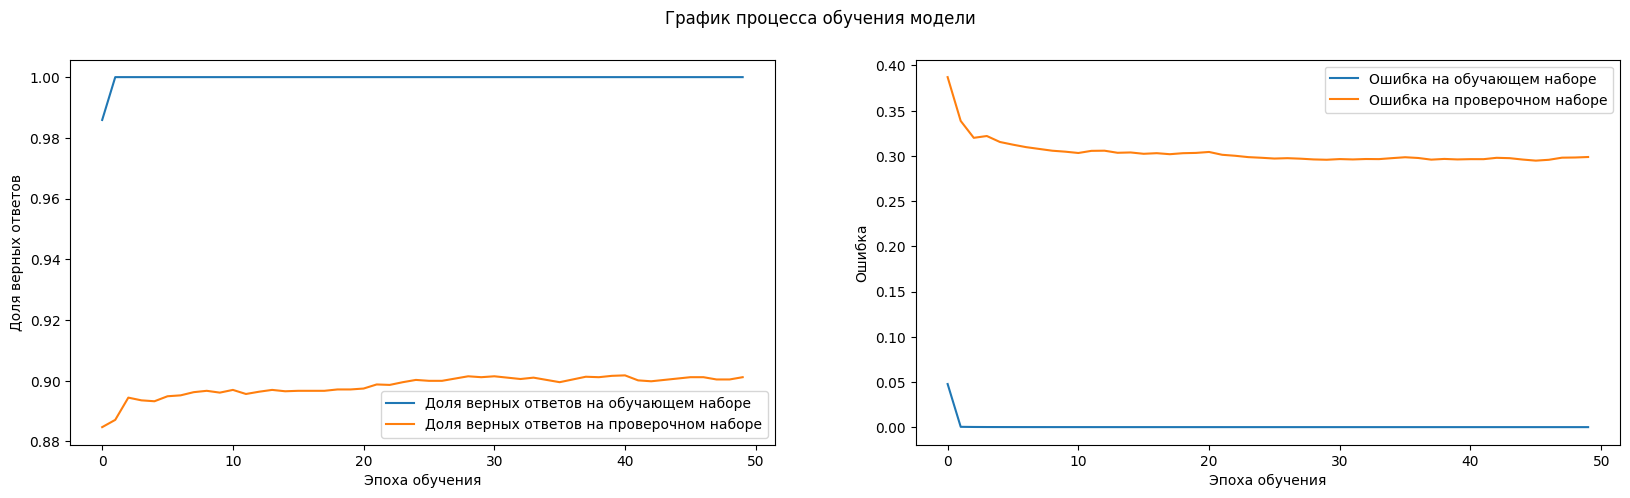

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


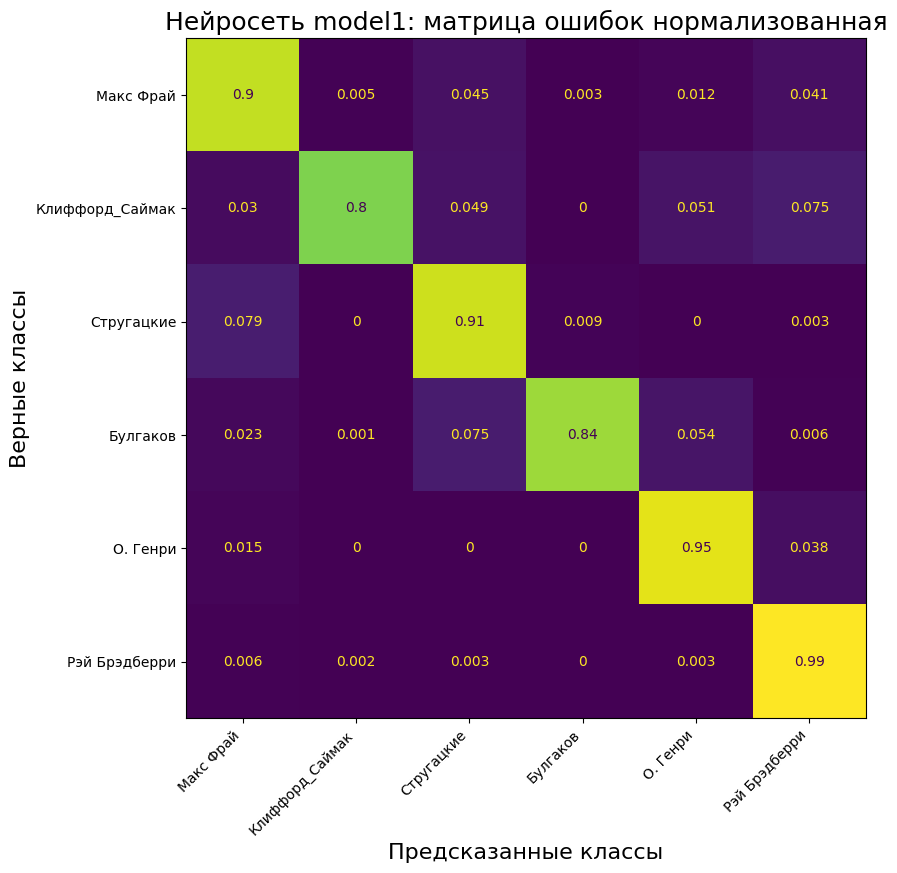

----------------------------------------------------------------------------------------------------
Нейросеть: model1
Класс: Макс Фрай             90% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Клиффорд_Саймак       80% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Стругацкие            91% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: Булгаков              84% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: О. Генри              95% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         99% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)

Средняя точность распознавания:  90%


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 300)                 │       6,000,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 300)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 300)                 │           1,200 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 30)                  │           9,030 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 30)                  │             120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 6)                   │             186 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,010,836 (22.93 MB)

 Trainable params: 6,010,176 (22.93 MB)

 Non-trainable params: 660 (2.58 KB)

Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9167 - loss: 0.3057 - val_accuracy: 0.8958 - val_loss: 0.4718
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 1.0000 - loss: 0.0076 - val_accuracy: 0.9031 - val_loss: 0.3806
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 0.9020 - val_loss: 0.3556
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9010 - val_loss: 0.3455
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.8984 - val_loss: 0.3450
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 1.0000 - loss: 8.4683e-04 - val_accuracy: 0.8996 - val_loss: 0.3378
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 6.4027e-04 - val_accuracy: 0.9001 - val_loss: 0.3335
Epoch 8/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 1.0000 - loss: 4.9228e-0

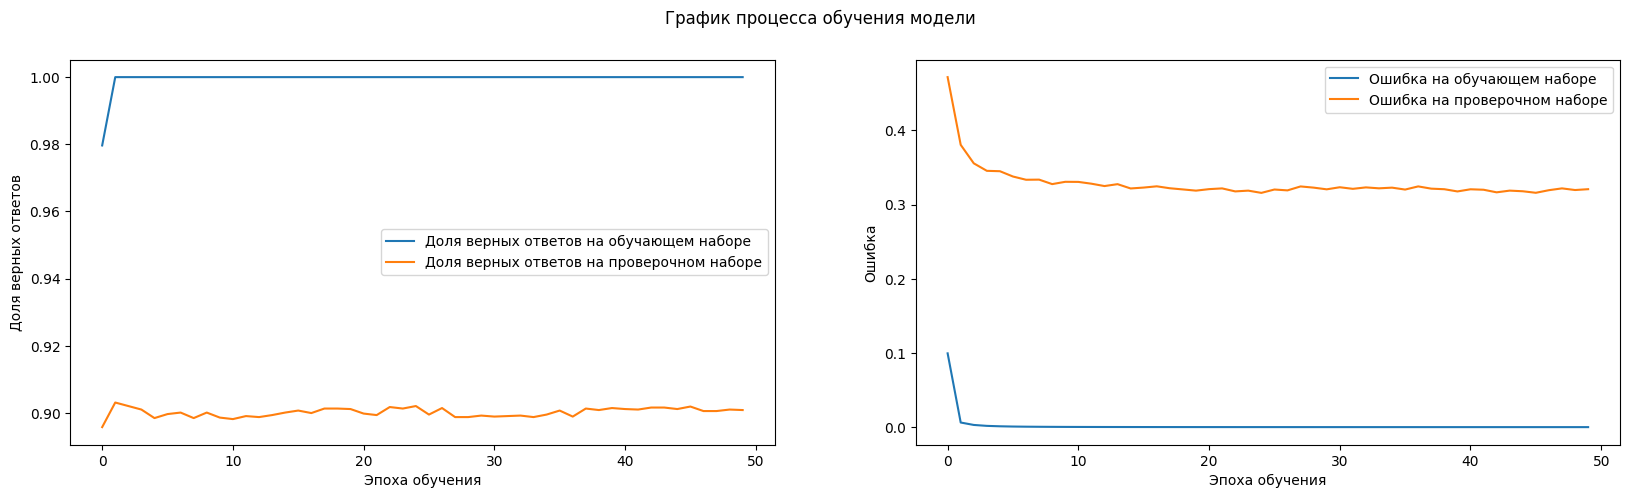

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


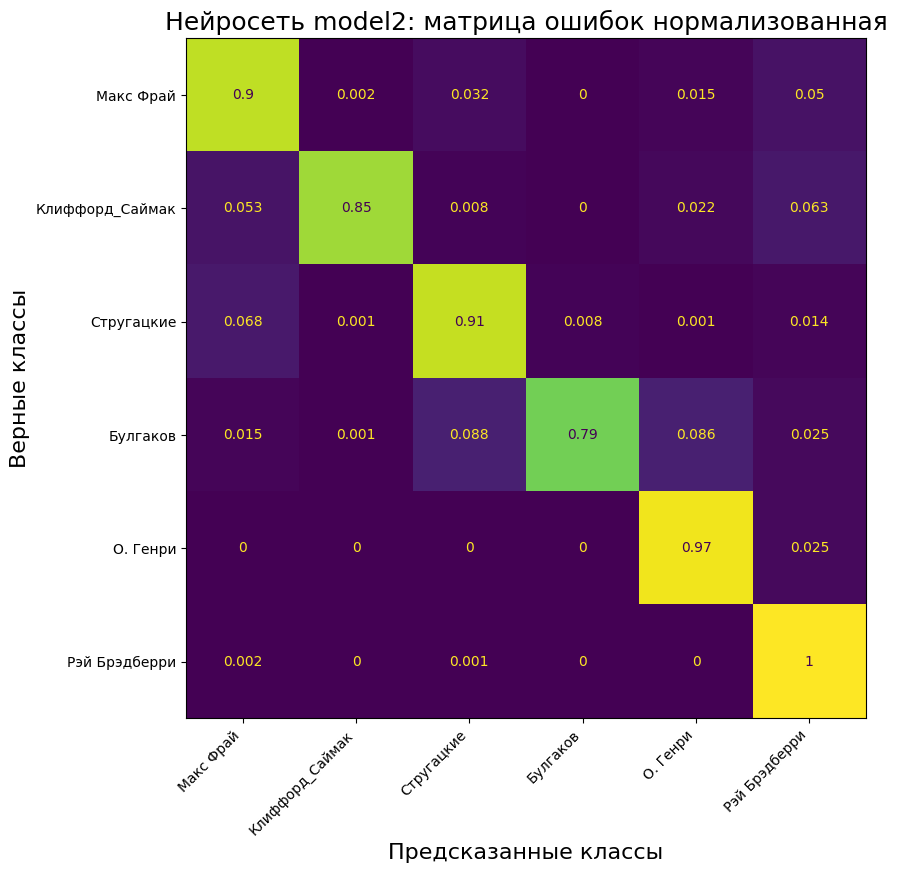

----------------------------------------------------------------------------------------------------
Нейросеть: model2
Класс: Макс Фрай             90% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Клиффорд_Саймак       85% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Стругацкие            91% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: Булгаков              78% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: О. Генри              98% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри        100% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)

Средняя точность распознавания:  90%


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 300)                 │       6,000,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 30)                  │           9,030 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 30)                  │             120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 6)                   │             186 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,009,636 (22.92 MB)

 Trainable params: 6,009,576 (22.92 MB)

 Non-trainable params: 60 (240.00 B)

Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9426 - loss: 0.2204 - val_accuracy: 0.8717 - val_loss: 0.4443
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 0.8480 - val_loss: 0.4587
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.8726 - val_loss: 0.4026
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 8.6096e-04 - val_accuracy: 0.8796 - val_loss: 0.3810
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 1.0000 - loss: 5.9888e-04 - val_accuracy: 0.8818 - val_loss: 0.3725
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 1.0000 - loss: 4.4869e-04 - val_accuracy: 0.8830 - val_loss: 0.3665
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 1.0000 - loss: 3.2777e-04 - val_accuracy: 0.8839 - val_loss: 0.3600
Epoch 8/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 2

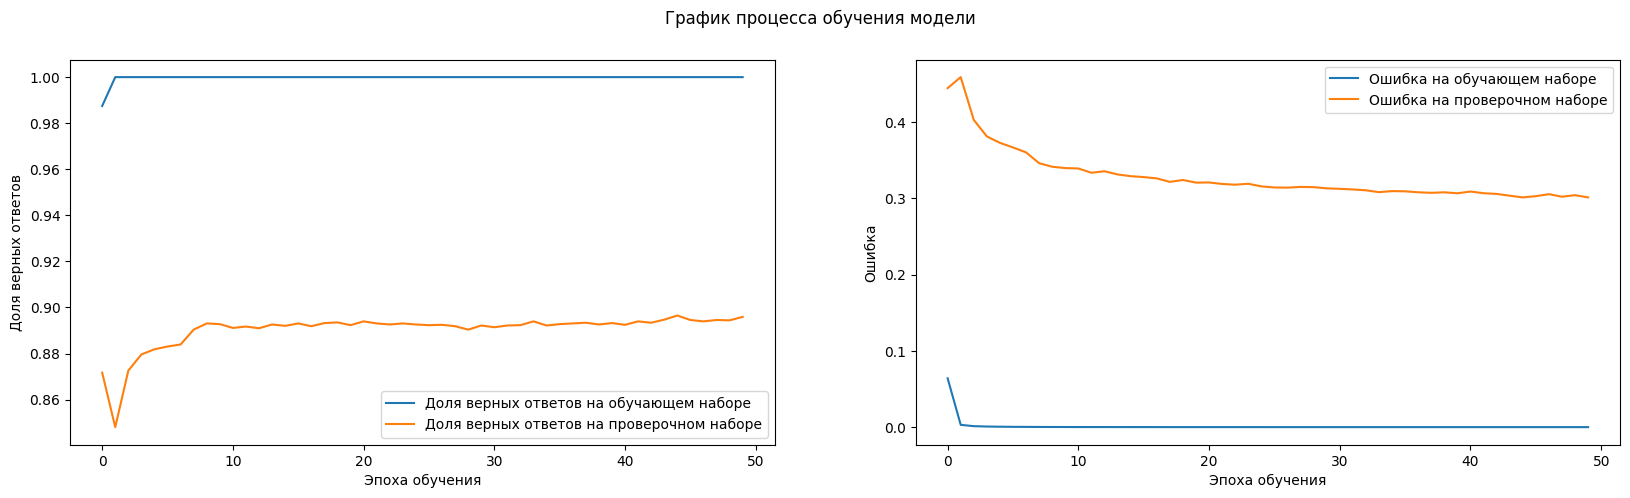

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


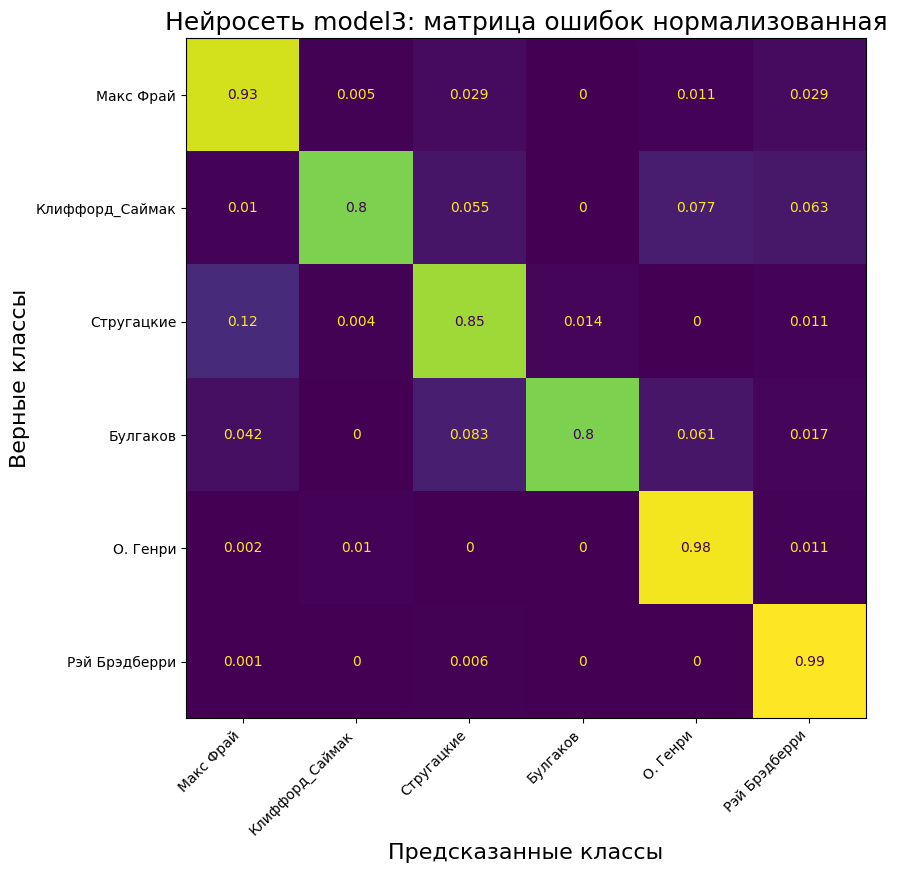

----------------------------------------------------------------------------------------------------
Нейросеть: model3
Класс: Макс Фрай             93% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Клиффорд_Саймак       80% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Стругацкие            85% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: Булгаков              80% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: О. Генри              98% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         99% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)

Средняя точность распознавания:  89%


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 600)                 │      12,000,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 600)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 200)                 │         120,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 200)                 │             800 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 30)                  │           6,030 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 30)                  │             120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 6)                   │             186 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,127,936 (46.26 MB)

 Trainable params: 12,127,476 (46.26 MB)

 Non-trainable params: 460 (1.80 KB)

Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.9083 - loss: 0.3230 - val_accuracy: 0.8551 - val_loss: 0.4931
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 0.0055 - val_accuracy: 0.8806 - val_loss: 0.4026
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.8832 - val_loss: 0.3819
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.8896 - val_loss: 0.3619
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 1.0000 - loss: 9.3166e-04 - val_accuracy: 0.8892 - val_loss: 0.3647
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 1.0000 - loss: 6.7125e-04 - val_accuracy: 0.8902 - val_loss: 0.3583
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 5.2643e-04 - val_accuracy: 0.8902 - val_loss: 0.3572
Epoch 8/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 1.0000 - loss: 3.69

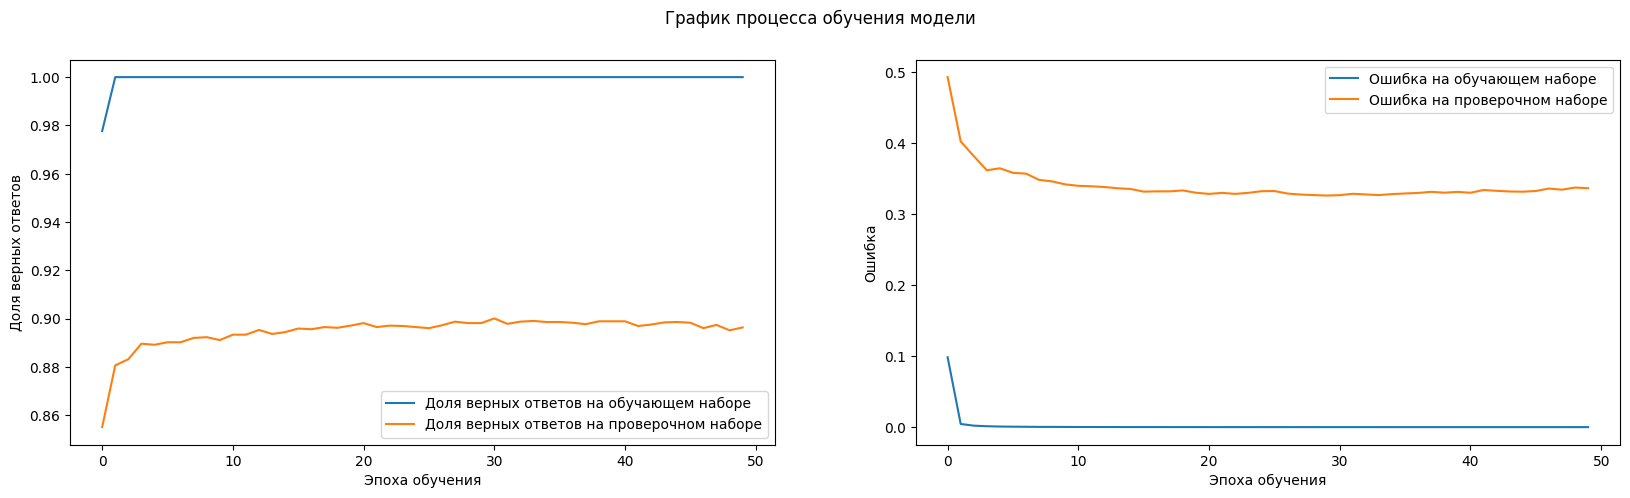

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


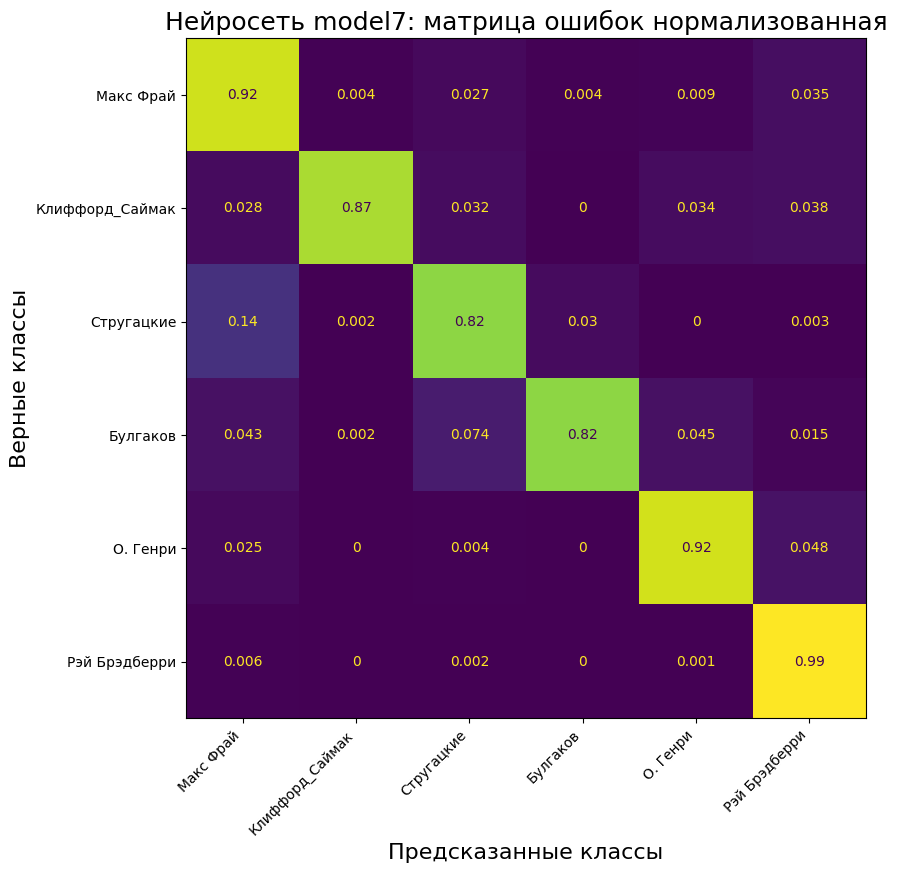

----------------------------------------------------------------------------------------------------
Нейросеть: model7
Класс: Макс Фрай             92% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Клиффорд_Саймак       87% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Стругацкие            82% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: Булгаков              82% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: О. Генри              92% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         99% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)

Средняя точность распознавания:  89%


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 400)                 │       8,000,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 200)                 │          80,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 200)                 │             800 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 30)                  │           6,030 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 30)                  │             120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 6)                   │             186 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,087,736 (30.85 MB)

 Trainable params: 8,087,276 (30.85 MB)

 Non-trainable params: 460 (1.80 KB)

Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.9153 - loss: 0.2871 - val_accuracy: 0.8959 - val_loss: 0.4144
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 0.8908 - val_loss: 0.3554
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.8907 - val_loss: 0.3397
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.8904 - val_loss: 0.3378
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 8.4323e-04 - val_accuracy: 0.8898 - val_loss: 0.3369
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 1.0000 - loss: 5.7817e-04 - val_accuracy: 0.8907 - val_loss: 0.3336
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 1.0000 - loss: 4.6144e-04 - val_accuracy: 0.8925 - val_loss: 0.3304
Epoch 8/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 3.543

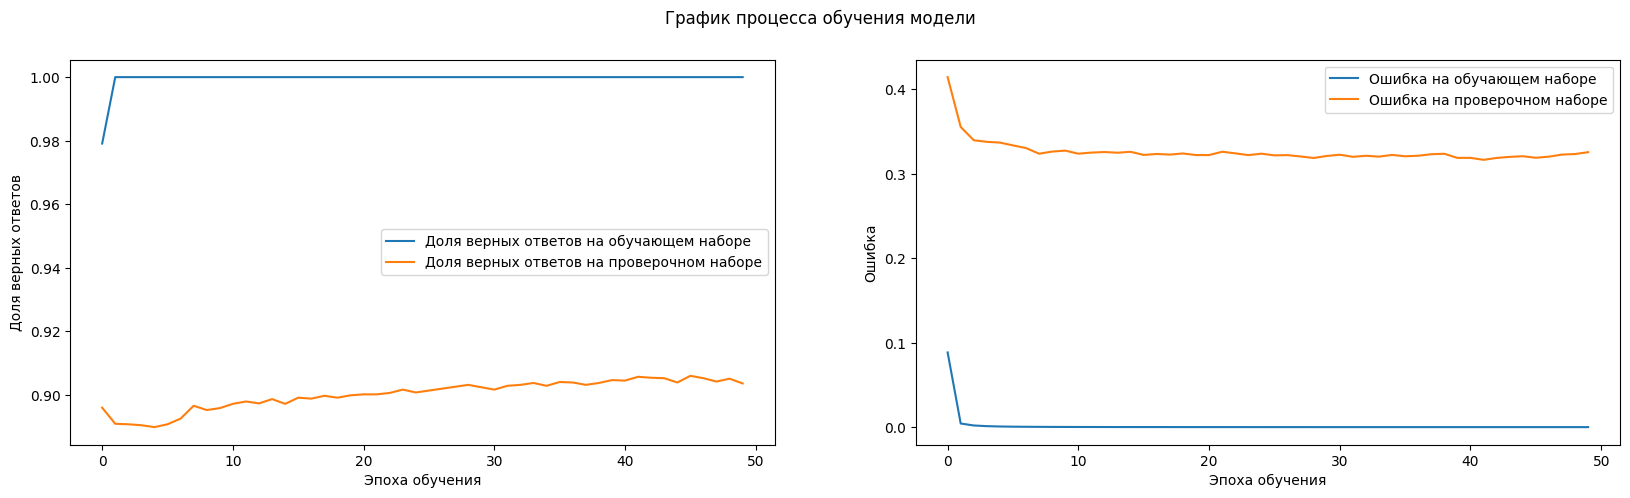

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


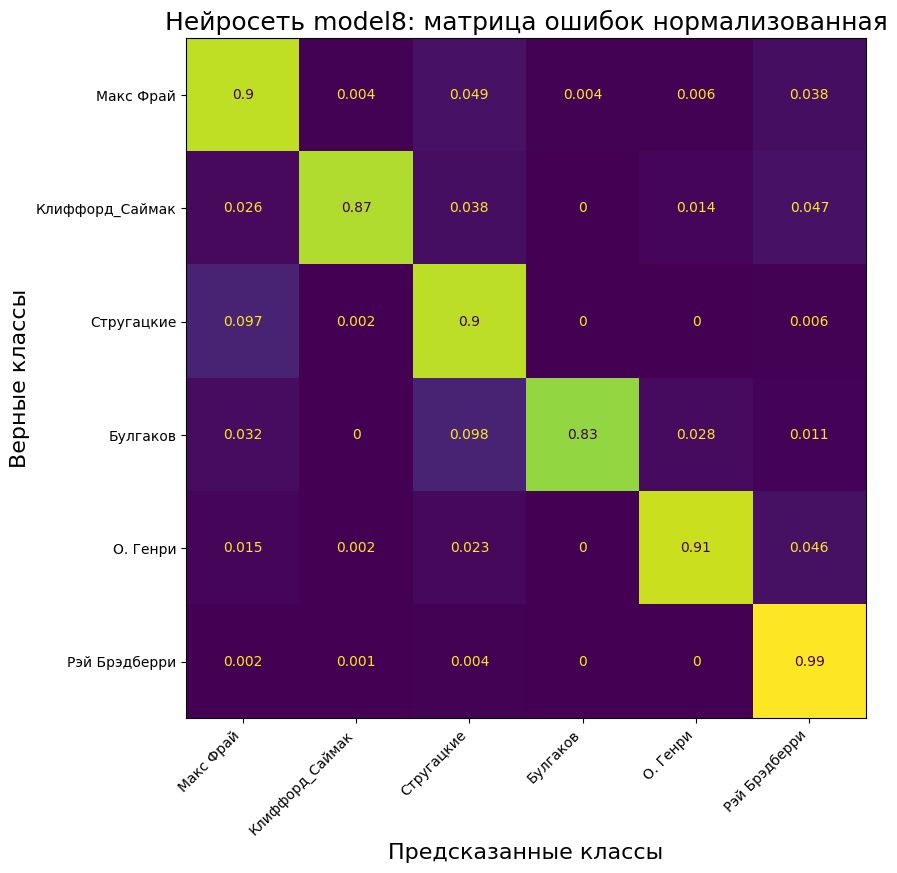

----------------------------------------------------------------------------------------------------
Нейросеть: model8
Класс: Макс Фрай             90% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Клиффорд_Саймак       87% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Стругацкие            90% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: Булгаков              83% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: О. Генри              91% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         99% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)

Средняя точность распознавания:  90%


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.6626 - loss: 1.2410 - val_accuracy: 0.2905 - val_loss: 1.7123
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9997 - loss: 0.0123 - val_accuracy: 0.3388 - val_loss: 1.4941
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 1.0000 - loss: 0.0034 - val_accuracy: 0.5695 - val_loss: 1.1533
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.6742 - val_loss: 0.9382
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.7064 - val_loss: 0.8744
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 1.0000 - loss: 7.6517e-04 - val_accuracy: 0.7172 - val_loss: 0.8572
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 1.0000 - loss: 6.4662e-04 - val_accuracy: 0.7199 - val_loss: 0.8624
Epoch 8/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 1.0000 - loss: 5.0420e

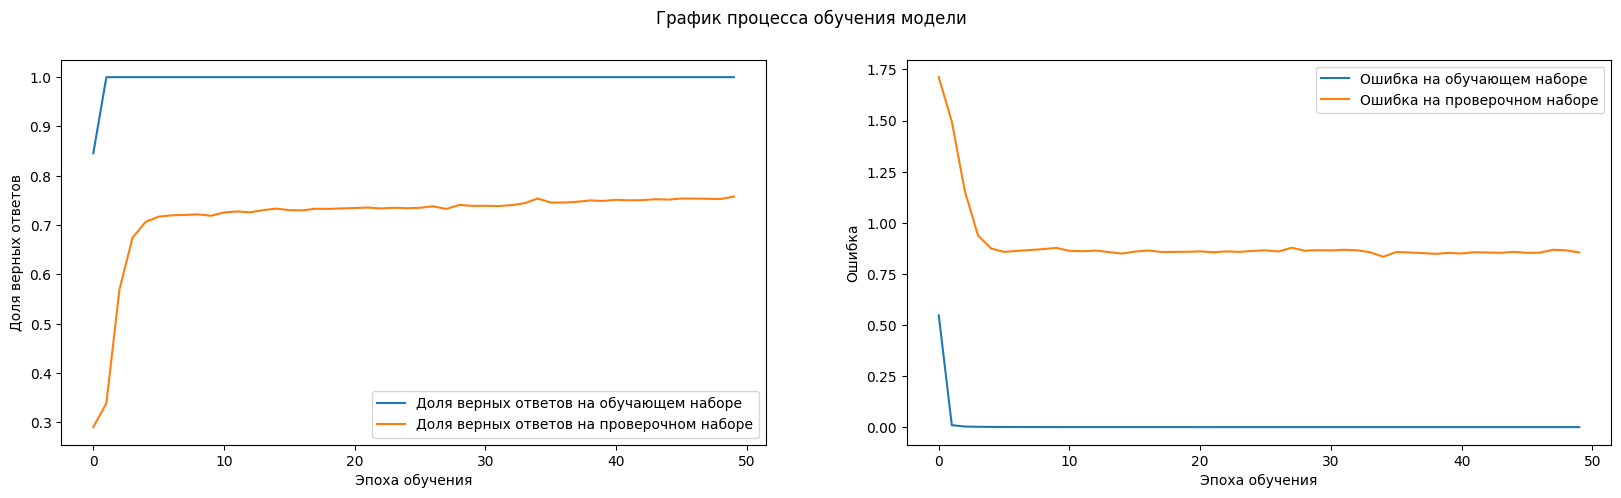

209/209 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


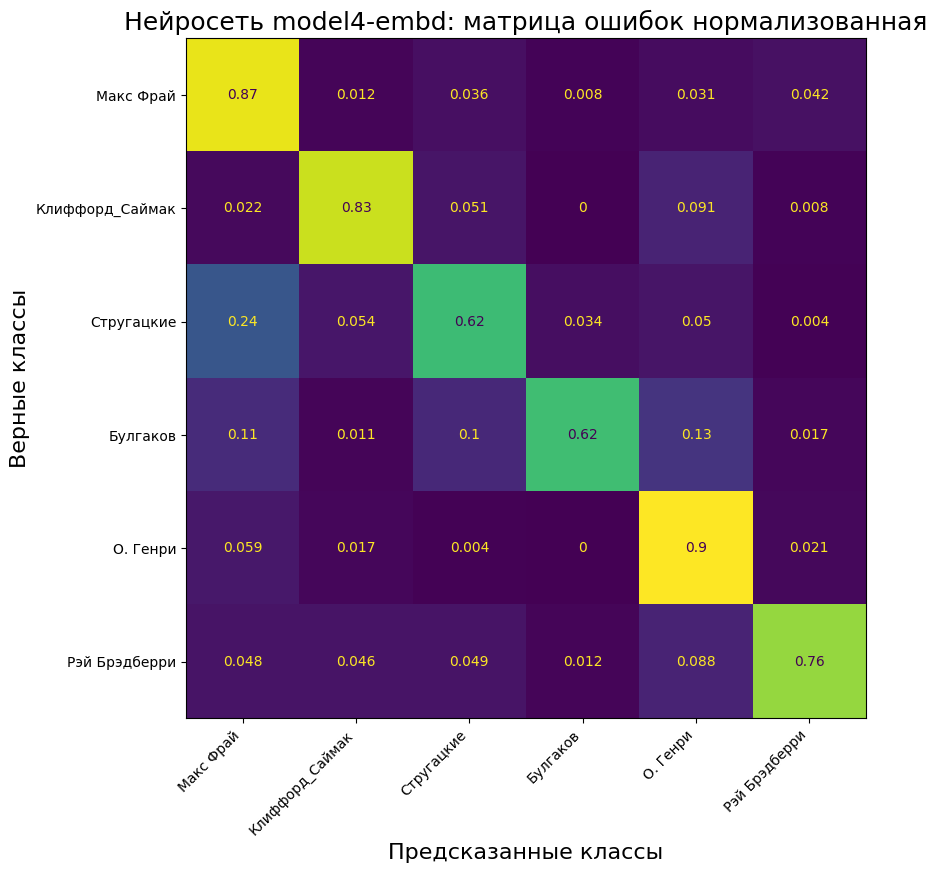

----------------------------------------------------------------------------------------------------
Нейросеть: model4-embd
Класс: Макс Фрай             87% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Клиффорд_Саймак       83% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Стругацкие            62% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: Булгаков              62% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: О. Генри              90% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         76% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)

Средняя точность распознавания:  77%


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_1                  │ ?                           │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.5348 - loss: 1.4917 - val_accuracy: 0.3525 - val_loss: 1.9200
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9985 - loss: 0.0196 - val_accuracy: 0.3983 - val_loss: 1.5897
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9994 - loss: 0.0084 - val_accuracy: 0.4982 - val_loss: 1.2662
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9998 - loss: 0.0045 - val_accuracy: 0.6220 - val_loss: 0.9965
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9994 - loss: 0.0040 - val_accuracy: 0.6383 - val_loss: 1.0050
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9998 - loss: 0.0023 - val_accuracy: 0.6687 - val_loss: 0.9715
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9999 - loss: 0.0018 - val_accuracy: 0.6844 - val_loss: 0.9315
Epoch 8/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0

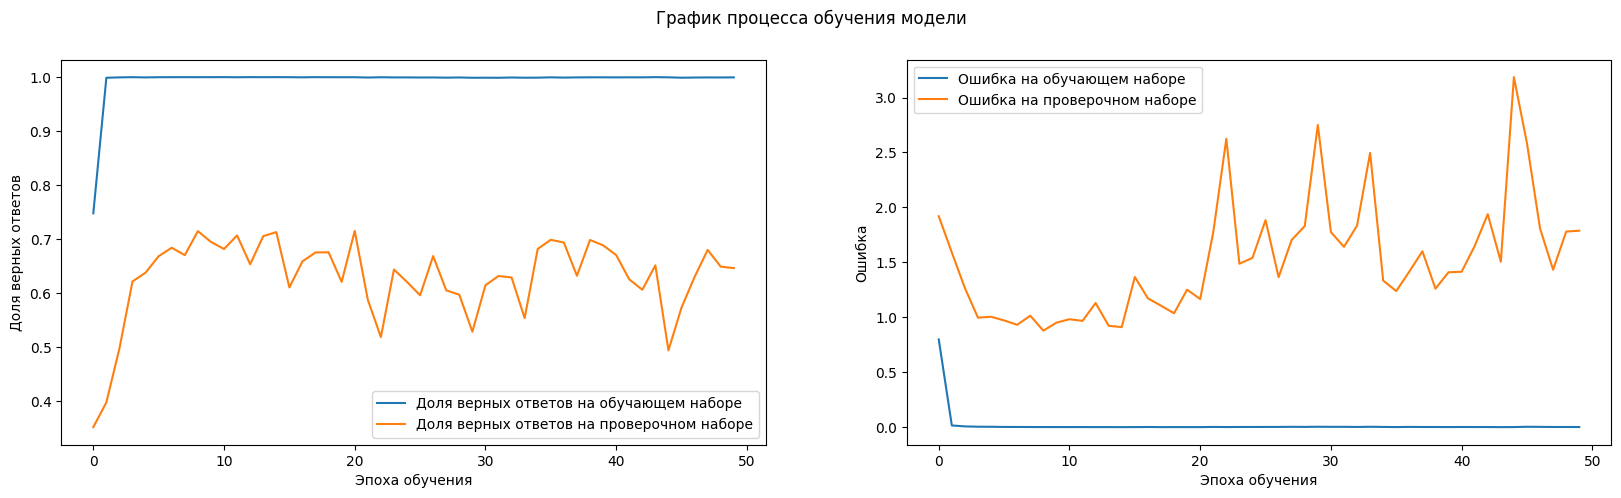

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


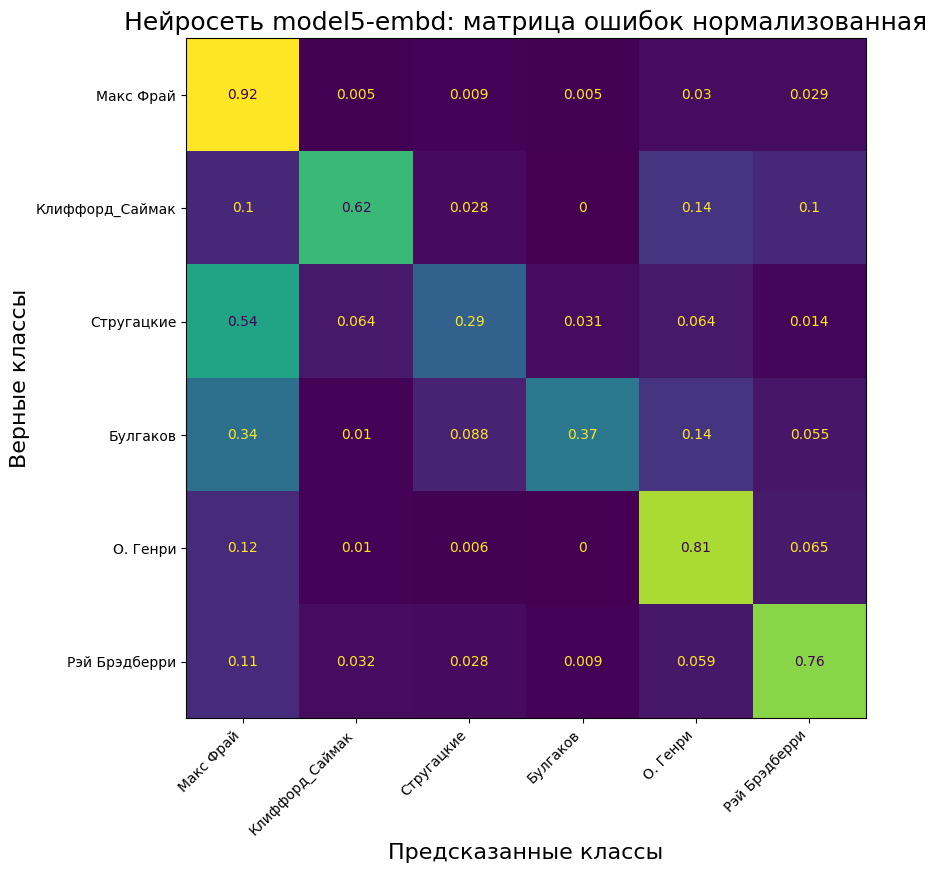

----------------------------------------------------------------------------------------------------
Нейросеть: model5-embd
Класс: Макс Фрай             92% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Клиффорд_Саймак       62% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Стругацкие            54% сеть отнесла к классу Макс Фрай            - НЕВЕРНО :-(
Класс: Булгаков              37% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: О. Генри              80% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         76% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)

Средняя точность распознавания:  63%


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_2                  │ ?                           │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 25s 112ms/step - accuracy: 0.6632 - loss: 1.3067 - val_accuracy: 0.3789 - val_loss: 1.9135
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.9998 - loss: 0.0113 - val_accuracy: 0.3439 - val_loss: 1.5383
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 0.5188 - val_loss: 1.2131
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.6494 - val_loss: 0.9722
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.7031 - val_loss: 0.8706
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 1.0000 - loss: 6.8213e-04 - val_accuracy: 0.7143 - val_loss: 0.8524
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 1.0000 - loss: 5.2298e-04 - val_accuracy: 0.7158 - val_loss: 0.8583
Epoch 8/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - accuracy: 1.0000 - loss: 

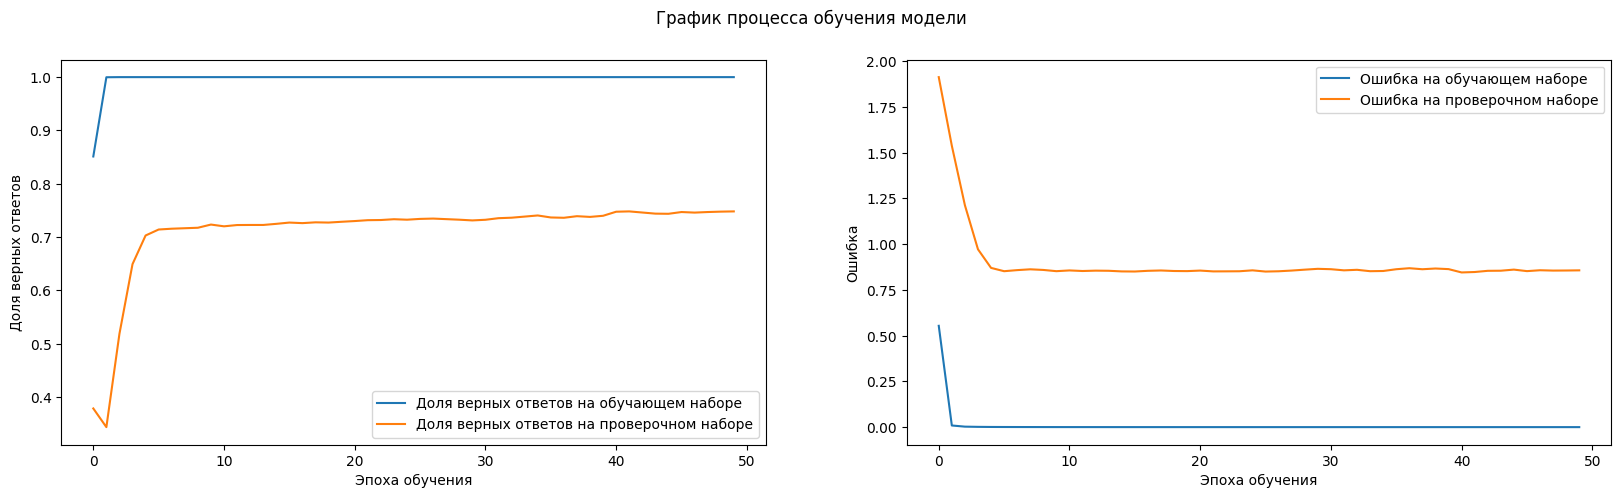

209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


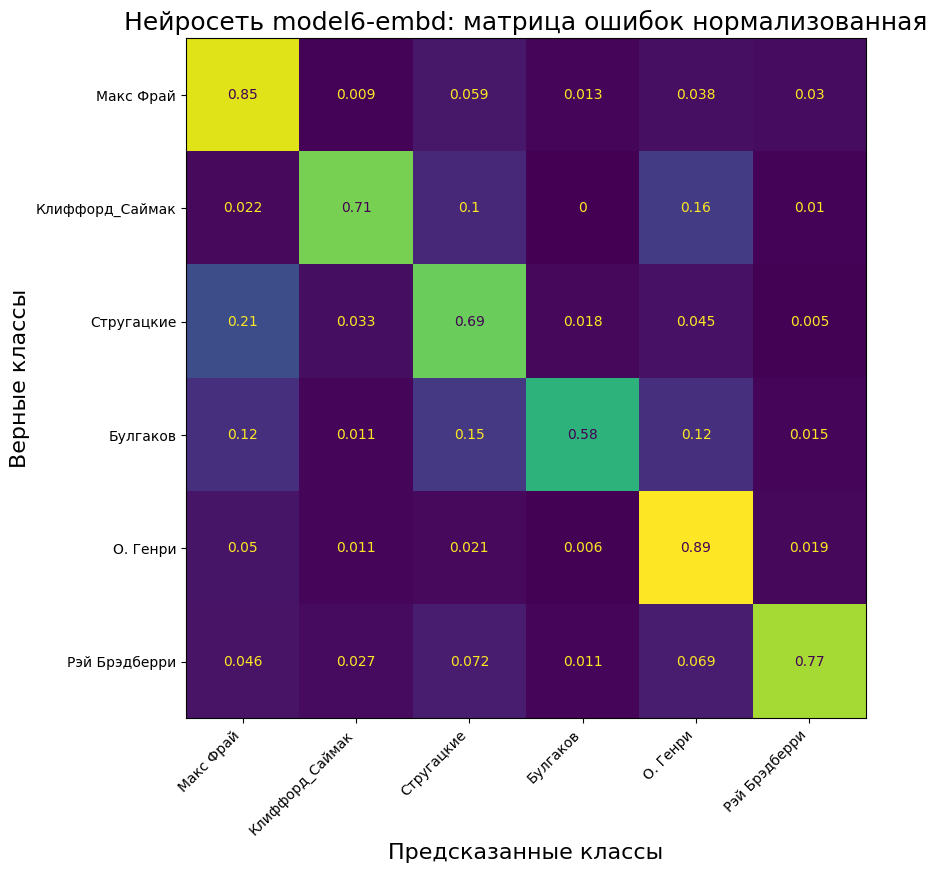

----------------------------------------------------------------------------------------------------
Нейросеть: model6-embd
Класс: Макс Фрай             85% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Клиффорд_Саймак       71% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Стругацкие            69% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: Булгаков              58% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: О. Генри              89% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         77% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)

Средняя точность распознавания:  75%


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_3                  │ ?                           │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 26s 127ms/step - accuracy: 0.6521 - loss: 1.2713 - val_accuracy: 0.3036 - val_loss: 1.7867
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 1.0000 - loss: 0.0162 - val_accuracy: 0.3774 - val_loss: 1.3944
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 0.5839 - val_loss: 1.0825
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.7267 - val_loss: 0.8082
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.7534 - val_loss: 0.7196
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.7517 - val_loss: 0.7185
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 1.0000 - loss: 9.7714e-04 - val_accuracy: 0.7441 - val_loss: 0.7258
Epoch 8/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 1.0000 - loss: 7.52

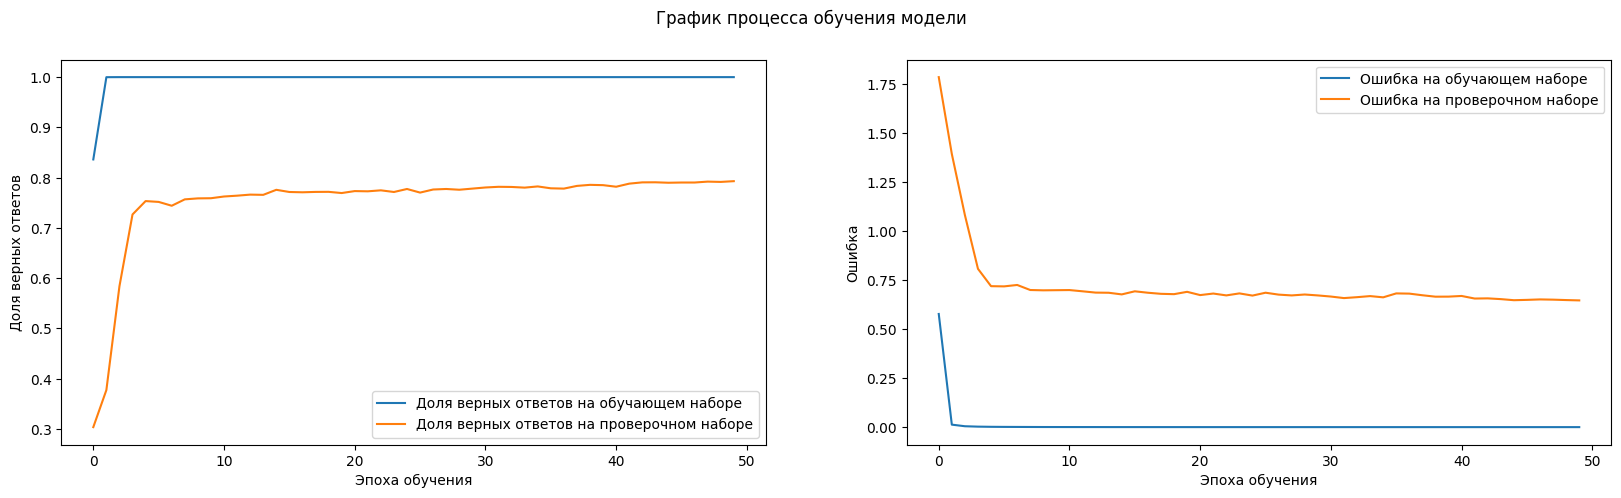

209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


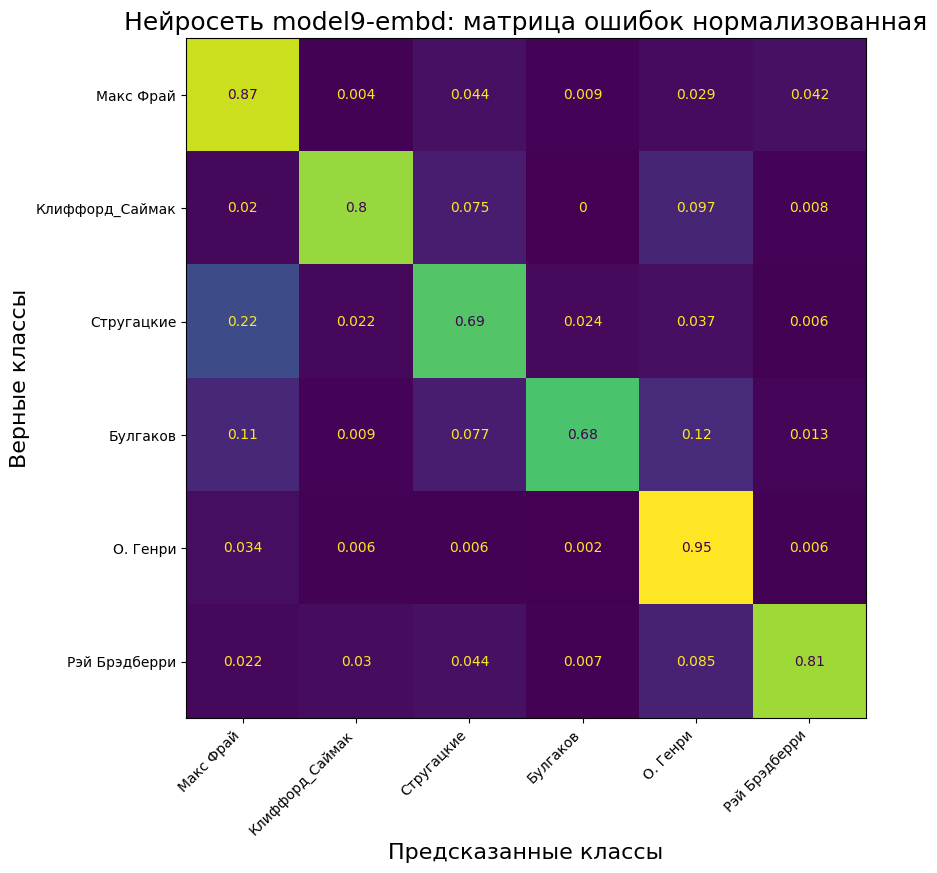

----------------------------------------------------------------------------------------------------
Нейросеть: model9-embd
Класс: Макс Фрай             87% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: Клиффорд_Саймак       80% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Стругацкие            69% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: Булгаков              68% сеть отнесла к классу Булгаков             - ВЕРНО :-)
Класс: О. Генри              95% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         81% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)

Средняя точность распознавания:  80%


In [17]:
# Создание моделей
model1 = Sequential()
# Первый полносвязный слой
model1.add(Dense(200, input_dim=VOCAB_SIZE, activation="relu"))
# Слой регуляризации Dropout
model1.add(Dropout(0.25))
# Слой пакетной нормализации
model1.add(BatchNormalization())
# Выходной полносвязный слой
model1.add(Dense(CLASS_COUNT, activation='softmax'))

model2 = Sequential()
# Первый полносвязный слой
model2.add(Dense(300, input_dim=VOCAB_SIZE, activation="relu"))
# Слой регуляризации Dropout
model2.add(Dropout(0.30))
# Сло2 пакетной нормализации
model2.add(BatchNormalization())
model2.add(Dense(30, activation="relu"))
model2.add(BatchNormalization())
# Выходной полносвязный слой
model2.add(Dense(CLASS_COUNT, activation='softmax'))

model3 = Sequential()
# Первый полносвязный слой
model3.add(Dense(300, input_dim=VOCAB_SIZE, activation="relu"))
model3.add(Dense(30, activation="relu"))
model3.add(BatchNormalization())
# Выходной полносвязный слой
model3.add(Dense(CLASS_COUNT, activation='softmax'))

model7 = Sequential()
# Первый полносвязный слой
model7.add(Dense(600, input_dim=VOCAB_SIZE, activation="relu"))
model7.add(Dropout(0.2))
model7.add(Dense(200, activation="relu"))
model7.add(BatchNormalization())
model7.add(Dense(30, activation="relu"))
model7.add(BatchNormalization())
# Выходной полносвязный слой
model7.add(Dense(CLASS_COUNT, activation='softmax'))

model8 = Sequential()
# Первый полносвязный слой
model8.add(Dense(400, input_dim=VOCAB_SIZE, activation="relu"))
model8.add(Dropout(0.2))
model8.add(Dense(200, activation="relu"))
model8.add(BatchNormalization())
model8.add(Dense(30, activation="relu"))
model8.add(BatchNormalization())
# Выходной полносвязный слой
model8.add(Dense(CLASS_COUNT, activation='softmax'))


#embedding models
model4 = Sequential()
model4.add(Embedding(VOCAB_SIZE, 200, input_length=WIN_SIZE))
model4.add(SpatialDropout1D(0.2))
model4.add(Flatten())
model4.add(BatchNormalization())
model4.add(Dense(200, activation="relu"))
model4.add(Dropout(0.2))
model4.add(BatchNormalization())
model4.add(Dense(CLASS_COUNT, activation='softmax'))

model5 = Sequential()
model5.add(Embedding(VOCAB_SIZE, 20, input_length=WIN_SIZE))
model5.add(SpatialDropout1D(0.2))
model5.add(Flatten())
model5.add(BatchNormalization())
model5.add(Dense(200, activation="relu"))
model5.add(Dropout(0.2))
model5.add(BatchNormalization())
model5.add(Dense(CLASS_COUNT, activation='softmax'))

model6 = Sequential()
model6.add(Embedding(VOCAB_SIZE, 500, input_length=WIN_SIZE))
model6.add(SpatialDropout1D(0.2))
model6.add(Flatten())
model6.add(BatchNormalization())
model6.add(Dense(200, activation="relu"))
model6.add(Dropout(0.2))
model6.add(BatchNormalization())
model6.add(Dense(CLASS_COUNT, activation='softmax'))

model9 = Sequential()
model9.add(Embedding(VOCAB_SIZE, 600, input_length=WIN_SIZE))
model9.add(SpatialDropout1D(0.4))
model9.add(Flatten())
model9.add(BatchNormalization())
model9.add(Dense(200, activation="relu"))
model9.add(Dropout(0.4))
model9.add(BatchNormalization())
model9.add(Dense(CLASS_COUNT, activation='softmax'))


models = [model1, model2, model3, model7, model8]
models2 = [model4, model5, model6, model9]
names = ['model1', 'model2', 'model3', 'model7', 'model8']
names2 = ['model4-embd', 'model5-embd', 'model6-embd', 'model9-embd']

for indx in range(len(models)):
    # Входные данные подаются в виде векторов bag of words
    compile_train_eval_model(models[indx],
                         x_train_01, y_train,
                         x_test_01, y_test,
                         class_labels=CLASS_LIST,
                         title=names[indx])

for indx in range(len(models2)):
    # Входные данные подаются в виде последовательностей индексов,
    # а не векторов bag of words
    compile_train_eval_model(models2[indx],
                         x_train, y_train,
                         x_test, y_test,
                         class_labels=CLASS_LIST,
                         title=names2[indx])



